In [1]:
##################### Plot Initial Conditions ######################
# The purpose of this script is to plot the initial conditions for
# the idealized Beaufort shelfbreak jet model. These will include
# vertical cross sections and surface things. 
#
# Notes:
# - This script heavily uses code written by Dylan Schlichting
#
#####################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import LogFormatterExponent
import warnings
import xarray as xr
import os
import xroms
from glob import glob
from xhistogram.xarray import histogram
from joblib import Parallel, delayed
warnings.filterwarnings("ignore") #turns off annoying warnings

In [3]:
# Load in the initial conditions 
# 500 m case, all runs
ini_conds = xr.open_dataset('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/ini_ice_500_m.nc')

In [4]:
# Load in the grid
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/grd_500_m.nc')

In [5]:
grid.f.values

array([[0.00013831, 0.00013831, 0.00013831, ..., 0.00013831, 0.00013831,
        0.00013831],
       [0.00013831, 0.00013831, 0.00013831, ..., 0.00013831, 0.00013831,
        0.00013831],
       [0.00013831, 0.00013831, 0.00013831, ..., 0.00013831, 0.00013831,
        0.00013831],
       ...,
       [0.00013831, 0.00013831, 0.00013831, ..., 0.00013831, 0.00013831,
        0.00013831],
       [0.00013831, 0.00013831, 0.00013831, ..., 0.00013831, 0.00013831,
        0.00013831],
       [0.00013831, 0.00013831, 0.00013831, ..., 0.00013831, 0.00013831,
        0.00013831]])

In [6]:
grid.x_rho

<xarray.DataArray 'x_rho' (eta_rho: 1002, xi_rho: 402)> Size: 3MB
[402804 values with dtype=float64]
Dimensions without coordinates: eta_rho, xi_rho

In [7]:
# Make coordinates for plotting
x_rho = grid.x_rho / 1000
x_u = grid.x_u / 1000
y_rho = grid.y_rho / 1000 
y_u = grid.y_u / 1000

In [8]:
ini_conds

<xarray.Dataset> Size: 699MB
Dimensions:             (s_rho: 40, eta_rho: 1002, xi_rho: 402, ocean_time: 1,
                         eta_u: 1002, xi_u: 401, eta_v: 1001, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 8kB 0 1 2 3 4 ... 997 998 999 1000 1001
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 129MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 129MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 129MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 129MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 3MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 3MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 3MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf
    Author:       Dylan Schlichting
    Created:      2025-12-29T14:52:59.098776

Text(0.5, 1.0, 'Along-Shore Velocity')

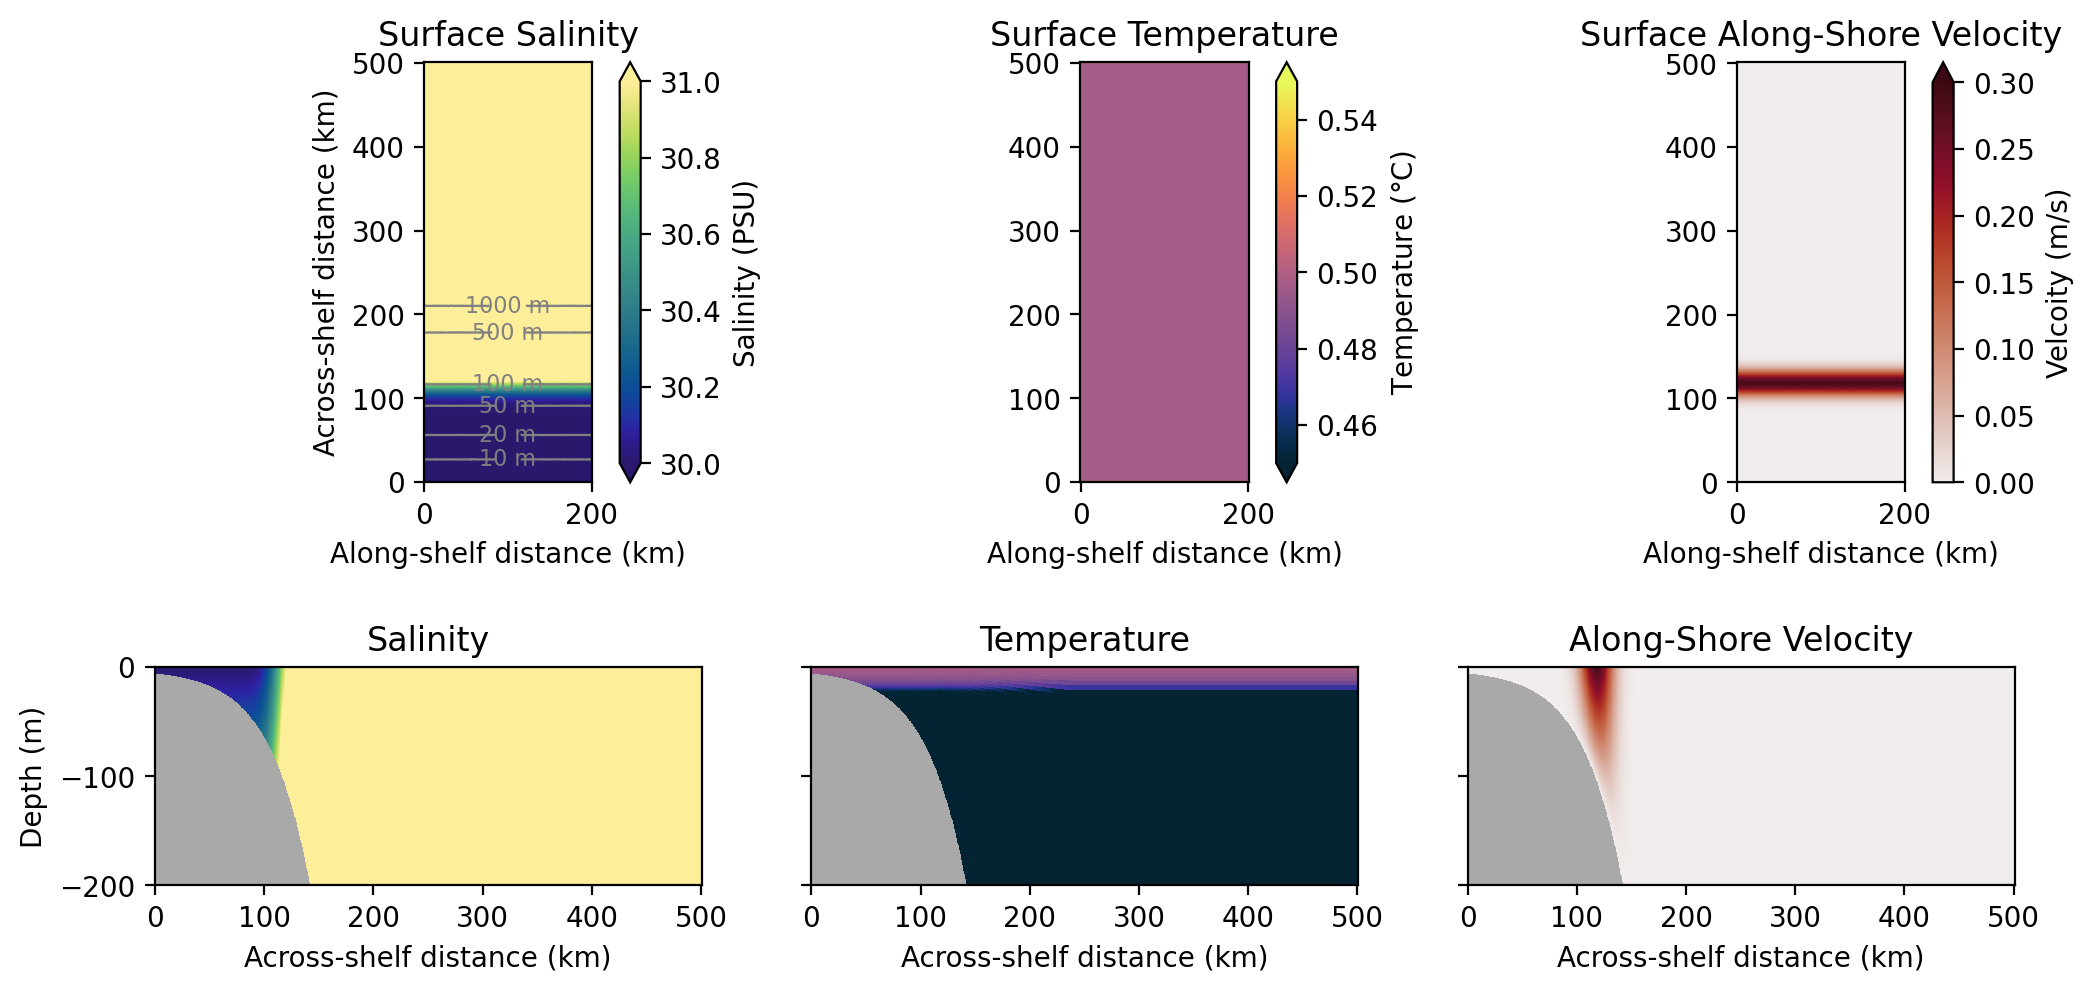

In [9]:
# Make a plot of surface and vertical things 

# Set the levels for things
lev_salt = np.arange(29,32,0.1)


# Make the figure
fig, ax = plt.subplots(2, 3, dpi=200, figsize=(12,6))

# Surface salinity
m1 = ax[0,0].pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.salt[-1,:,:], cmap=cmo.haline,
                        vmin=30, vmax=31)
fig.colorbar(m1, ax=ax[0,0], label='Salinity (PSU)', extend='both')
# Contours for bathymetry
positions = [(100, 10),(100,60),(100,90),(100,140),(100,160),(100,210)]
cs = ax[0,0].contour(grid.x_rho/1000, grid.y_rho/1000, grid.h, levels=[10, 20, 50, 100, 500, 1000],
                colors='gray', linewidths=0.8)
ax[0,0].clabel(cs, fmt='%d m', manual=positions, inline=True, fontsize=8, colors='gray')

# Surface temperature 
m2 = ax[0,1].pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.temp[-1,:,:], cmap=cmo.thermal,
                        vmin=0.45, vmax=0.55)
fig.colorbar(m2, ax=ax[0,1], label='Temperature ($\degree$C)', extend='both')

# Surface along-shore velocity 
m3 = ax[0,2].pcolormesh(grid.x_u/1000, grid.y_u/1000, ini_conds.u[0,-1,:,:], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
fig.colorbar(m3, ax=ax[0,2], label='Velcoity (m/s)', extend='max')

# Set consistent axis limits
for r in range(3):
    ax[0,r].set_xlabel('Along-shelf distance (km)')
    ax[0,r].set_aspect(1)

# Vertical cross sections
# Salinity
m4 = ax[1,0].pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.salt[:,:,201], cmap=cmo.haline,
                        vmin=30, vmax=31)
#fig.colorbar(m4, ax=ax[1,0], label='(PSU)', extend='both')

# Temperature 
m5 = ax[1,1].pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.temp[:,:,201], cmap=cmo.thermal,
                        vmin=0.45, vmax=0.55)
#fig.colorbar(m5, ax=ax[1,1], label='($\degree$C)', extend='both')

# U
m6 = ax[1,2].pcolormesh(grid.y_u[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.u[0,:,:,201], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
#fig.colorbar(m6, ax=ax[1,2], label='Velcoity (m/s)', extend='max')

for rr in range(3):
    # Set y lim
    ax[1,rr].set_ylim(-200,0)
    ax[1,rr].set_facecolor('darkgray')
    ax[1,rr].set_aspect(1.0)

# Label the axes
ax[0,0].set_ylabel('Across-shelf distance (km)')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_xlabel('Across-shelf distance (km)')
ax[1,1].set_xlabel('Across-shelf distance (km)')
ax[1,2].set_xlabel('Across-shelf distance (km)')
ax[1,1].set_yticklabels('')
ax[1,2].set_yticklabels('')

# Give the subplots titles
ax[0,0].set_title('Surface Salinity')
ax[0,1].set_title('Surface Temperature')
ax[0,2].set_title('Surface Along-Shore Velocity')
ax[1,0].set_title('Salinity')
ax[1,1].set_title('Temperature')
ax[1,2].set_title('Along-Shore Velocity')

# fig.canvas.draw()

# for c in range(3):
#     top_pos = ax[0, c].get_position()
#     bottom_pos = ax[1, c].get_position()

#     top_center = top_pos.y0 + top_pos.height / 2
#     bottom_center = bottom_pos.y0 + bottom_pos.height / 2

#     dy = top_center - bottom_center

#     # Shift bottom axes by dy (relative move)
#     ax[1, c].set_position([
#         bottom_pos.x0,
#         bottom_pos.y0 + dy,
#         bottom_pos.width,
#         bottom_pos.height
#     ])


# 

In [10]:
ini_conds

<xarray.Dataset> Size: 699MB
Dimensions:             (s_rho: 40, eta_rho: 1002, xi_rho: 402, ocean_time: 1,
                         eta_u: 1002, xi_u: 401, eta_v: 1001, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 8kB 0 1 2 3 4 ... 997 998 999 1000 1001
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 129MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 129MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 129MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 129MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 3MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 3MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 3MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf
    Author:       Dylan Schlichting
    Created:      2025-12-29T14:52:59.098776

In [11]:
# Calculate density so we can add isopycnals 
# to the cross sections 

# Calculate density in the domain to use...or just
# for the transect if this causes the kernel to crash 
# Calculate density again but using linear equation of state 
# Set the coefficients/reference values from ROMS output
R0 = 1025 # kg/m3
T0 = 0.5 # Celsius
S0 =  31 # PSU/nondimensional
T_coeff = 0.00017 # 1/Celsius
S_coeff = 0.00076 # 1/nondimensional

# Now calculate density
ini_rho = R0 * (1 - (T_coeff*(ini_conds.temp-T0)) + (S_coeff*(ini_conds.salt-S0)))


In [12]:
np.max(ini_rho)

<xarray.DataArray ()> Size: 8B
array(1030.13042092)

In [13]:
np.shape(ini_rho)

(40, 1002, 402)

Text(0.594, 0.12, 'c)')

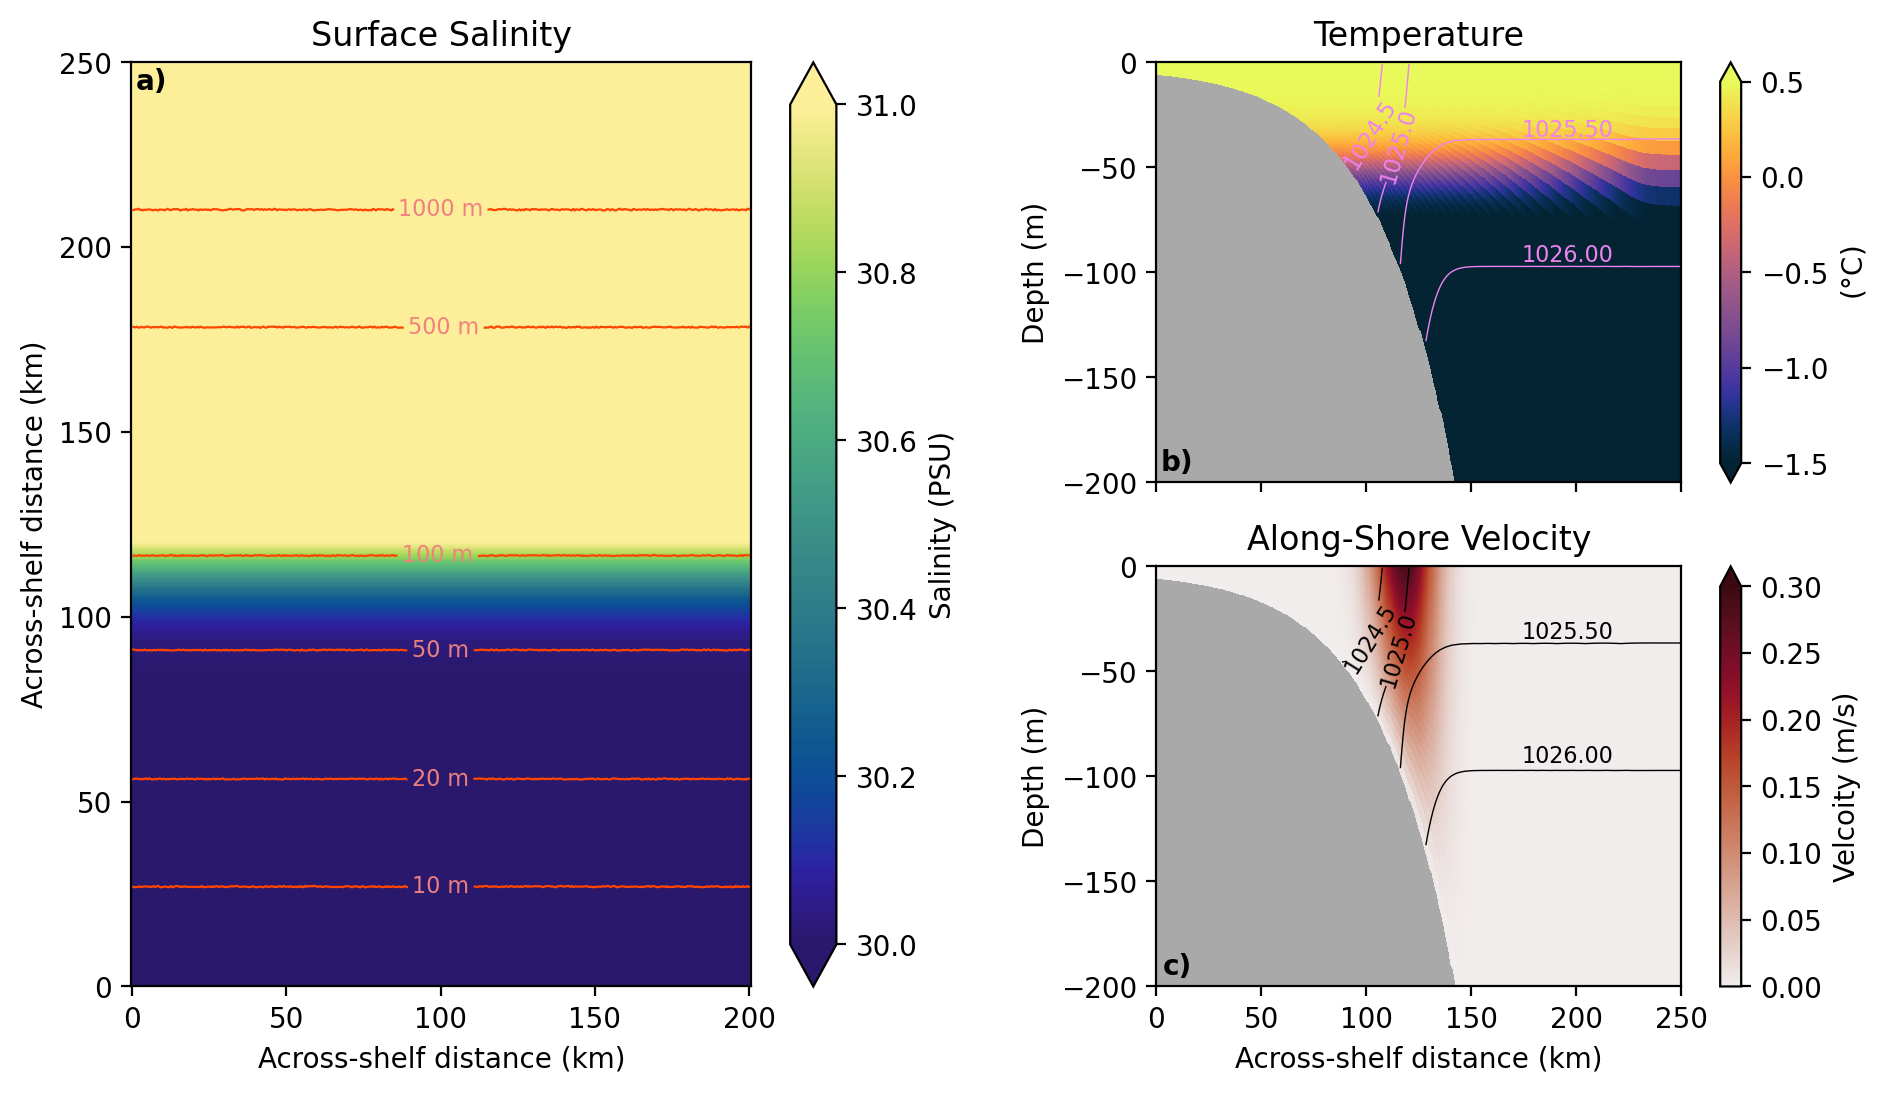

In [14]:
# Make a plot that just has surface salinity 
# and then the transects for the other variables 

# Set the levels for things
lev_salt = np.arange(29,32,0.1)

# Set density levels
lev_dens = np.arange(1024.0, 1030.0, 0.5)
label_levels = np.arange(1024, 1030, 1.0)

# Make the figure
fig = plt.figure(dpi=200, figsize=(11,6))

gs = fig.add_gridspec(2,2)
ax1 = fig.add_subplot(gs[:,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,1])

# Set axis limits
ax2.set_ylim(-200,0)
ax2.set_xlim(0,250)
ax2.set_facecolor('darkgray')
ax2.set_aspect(1.0)
ax3.set_ylim(-200,0)
ax3.set_xlim(0,250)
ax3.set_facecolor('darkgray')
ax3.set_aspect(1.0)

# Surface salinity
m1 = ax1.pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.salt[-1,:,:], cmap=cmo.haline,
                        vmin=30, vmax=31)
fig.colorbar(m1, ax=ax1, label='Salinity (PSU)', extend='both')
# Contours for bathymetry
positions = [(100, 10),(100,60),(100,90),(100,140),(100,160),(100,210)]
cs = ax1.contour(grid.x_rho/1000, grid.y_rho/1000, grid.h, levels=[10, 20, 50, 100, 500, 1000],
                colors='orangered', linewidths=0.8)
ax1.clabel(cs, fmt='%d m', manual=positions, inline=True, fontsize=8, colors='lightcoral')
ax1.set_ylim(0,250)

# Vertical cross sections
# Temperature 
m5 = ax2.pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.temp[:,:,201], cmap=cmo.thermal,
                        vmin=-1.5, vmax=0.50)
fig.colorbar(m5, ax=ax2, label='($\degree$C)', extend='both')
# Plot density contours
y_sec = grid.y_rho[:, 201]
y_2d = np.array([y_sec]*40)                          
c1 = ax2.contour(y_2d/1000, ini_conds.z_rho[0,:,:,201], ini_rho[:,:,201],
        levels=lev_dens, colors='violet', linewidths=0.5)
# manual_positions = []
# for collection in c1.collections:
#     for path in collection.get_paths():
#         v = path.vertices
#         manual_positions.append(v[len(v)//2])
ax2.clabel(c1, levels=c1.levels, inline=True, inline_spacing=0, fmt='%1.1f', fontsize=8)
#c1.collections[i].set_clip_on(False)
# Manually label contours that won't show up
fig.text(0.757, 0.818, '1025.50', color='violet', fontsize=8)
fig.text(0.757, 0.714, '1026.00', color='violet', fontsize=8)

# U
m6 = ax3.pcolormesh(grid.y_u[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.u[0,:,:,201], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
fig.colorbar(m6, ax=ax3, label='Velcoity (m/s)', extend='max')
# Plot denisty conoturs
c2 = ax3.contour(y_2d/1000, ini_conds.z_rho[0,:,:,201], ini_rho[:,:,201],
        levels=lev_dens, colors='black', linewidths=0.5)
ax3.clabel(c2, levels=c2.levels, inline=True, inline_spacing=0, fmt='%1.1f', fontsize=8)
# Manually label contours that won't show up
fig.text(0.757, 0.400, '1025.50', color='black', fontsize=8)
fig.text(0.757, 0.296, '1026.00', color='black', fontsize=8)

# Label the axes
ax1.set_ylabel('Across-shelf distance (km)')
ax1.set_xlabel('Across-shelf distance (km)')
ax1.set_title('Surface Salinity')
ax2.set_ylabel('Depth (m)')
#ax2.set_xlabel('Across-shelf distance (km)')
ax2.set_xticklabels('')
ax2.set_title('Temperature')
ax3.set_ylabel('Depth (m)')
ax3.set_xlabel('Across-shelf distance (km)')
ax3.set_title('Along-Shore Velocity')

# Add subplot labels
fig.text(0.127, 0.857, 'a)', color='black', weight='bold')
fig.text(0.593, 0.540, 'b)', color='black', weight='bold')
fig.text(0.594, 0.120, 'c)', color='black', weight='bold')






In [17]:
# Set the grid resolutions
dx = 500 # meters
dy = 500 # meters

Text(0.594, 0.12, 'c)')

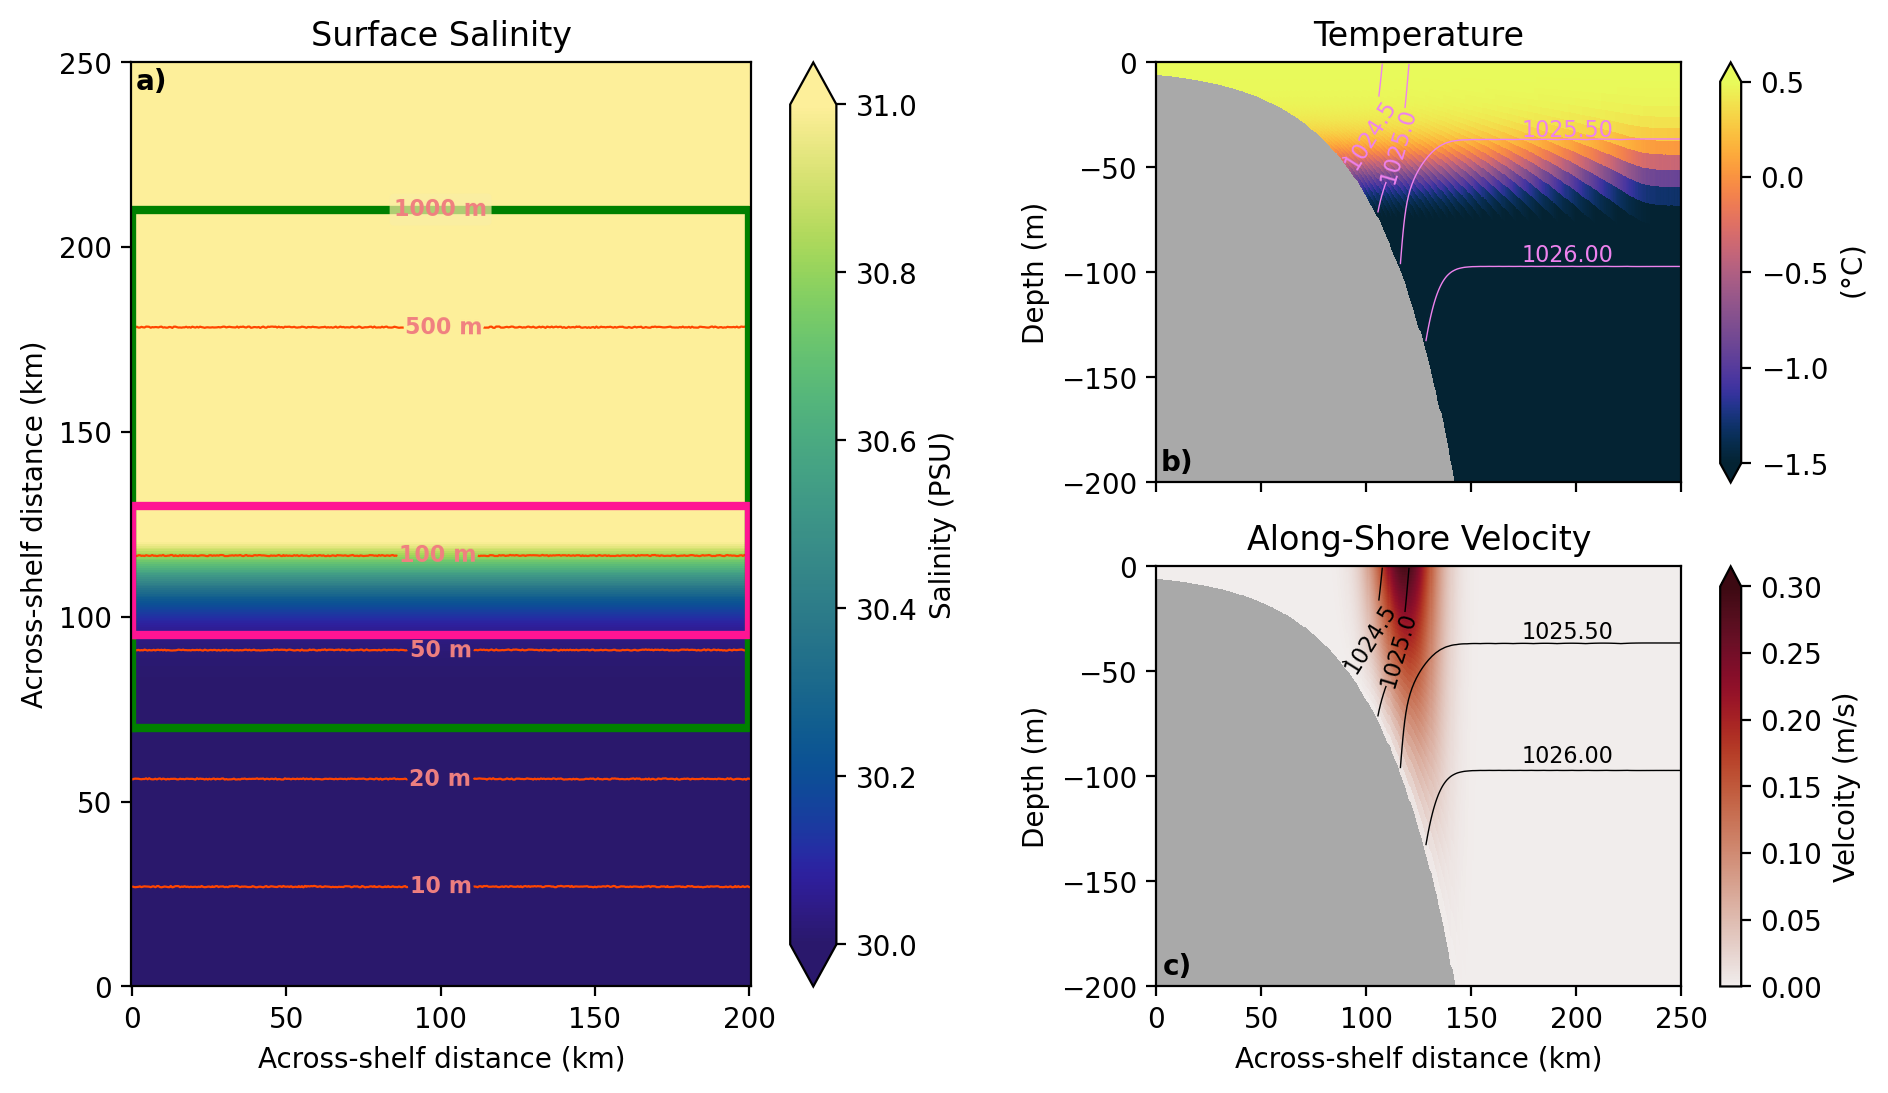

In [25]:
# Make another version but with the boxed regions added in

# Make the figure
fig = plt.figure(dpi=200, figsize=(11,6))

gs = fig.add_gridspec(2,2)
ax1 = fig.add_subplot(gs[:,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,1])

# Set axis limits
ax2.set_ylim(-200,0)
ax2.set_xlim(0,250)
ax2.set_facecolor('darkgray')
ax2.set_aspect(1.0)
ax3.set_ylim(-200,0)
ax3.set_xlim(0,250)
ax3.set_facecolor('darkgray')
ax3.set_aspect(1.0)

# Surface salinity
m1 = ax1.pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.salt[-1,:,:], cmap=cmo.haline,
                        vmin=30, vmax=31)
fig.colorbar(m1, ax=ax1, label='Salinity (PSU)', extend='both')
# Contours for bathymetry
positions = [(100, 10),(100,60),(100,90),(100,140),(100,160),(100,210)]
cs = ax1.contour(grid.x_rho/1000, grid.y_rho/1000, grid.h, levels=[10, 20, 50, 100, 500, 1000],
                colors='orangered', linewidths=0.8)
clabels = ax1.clabel(cs, fmt='%d m', manual=positions, inline=True, fontsize=8, colors='lightcoral')
for l in clabels:
    l.set_fontweight('bold')

# Add shading to the last label only
last_label = clabels[-1]
last_label.set_bbox(dict(
    facecolor='#F9EEA4',   # background color
    edgecolor='none',    # no border
    alpha=0.7,           # transparency
    boxstyle='round,pad=0.2'
))

ax1.set_ylim(0,250)
# Add the region of the domain that we are analyzing for bulk things 
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
# Plot Box 1
ax1.plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='green', linestyle='-', linewidth=3)

# Box 2 (vorticity - strain PDF)
box_min_x_02 = 0
box_max_x_02 = 200
box_min_y_02 = (190*dy)/1000
box_max_y_02 = (260*dx)/1000
# Plot Box 1
ax1.plot([box_min_x_02, box_max_x_02, box_max_x_02, box_min_x_02, box_min_x_02],
        [box_min_y_02, box_min_y_02, box_max_y_02, box_max_y_02, box_min_y_02],
        color='deeppink', linestyle='-', linewidth=3)


# Vertical cross sections
# Temperature 
m5 = ax2.pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.temp[:,:,201], cmap=cmo.thermal,
                        vmin=-1.5, vmax=0.50)
fig.colorbar(m5, ax=ax2, label='($\degree$C)', extend='both')
# Plot density contours
y_sec = grid.y_rho[:, 201]
y_2d = np.array([y_sec]*40)                          
c1 = ax2.contour(y_2d/1000, ini_conds.z_rho[0,:,:,201], ini_rho[:,:,201],
        levels=lev_dens, colors='violet', linewidths=0.5)
# manual_positions = []
# for collection in c1.collections:
#     for path in collection.get_paths():
#         v = path.vertices
#         manual_positions.append(v[len(v)//2])
ax2.clabel(c1, levels=c1.levels, inline=True, inline_spacing=0, fmt='%1.1f', fontsize=8)
#c1.collections[i].set_clip_on(False)
# Manually label contours that won't show up
fig.text(0.757, 0.818, '1025.50', color='violet', fontsize=8)
fig.text(0.757, 0.714, '1026.00', color='violet', fontsize=8)

# U
m6 = ax3.pcolormesh(grid.y_u[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.u[0,:,:,201], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
fig.colorbar(m6, ax=ax3, label='Velcoity (m/s)', extend='max')
# Plot denisty conoturs
c2 = ax3.contour(y_2d/1000, ini_conds.z_rho[0,:,:,201], ini_rho[:,:,201],
        levels=lev_dens, colors='black', linewidths=0.5)
ax3.clabel(c2, levels=c2.levels, inline=True, inline_spacing=0, fmt='%1.1f', fontsize=8)
# Manually label contours that won't show up
fig.text(0.757, 0.400, '1025.50', color='black', fontsize=8)
fig.text(0.757, 0.296, '1026.00', color='black', fontsize=8)

# Label the axes
ax1.set_ylabel('Across-shelf distance (km)')
ax1.set_xlabel('Across-shelf distance (km)')
ax1.set_title('Surface Salinity')
ax2.set_ylabel('Depth (m)')
#ax2.set_xlabel('Across-shelf distance (km)')
ax2.set_xticklabels('')
ax2.set_title('Temperature')
ax3.set_ylabel('Depth (m)')
ax3.set_xlabel('Across-shelf distance (km)')
ax3.set_title('Along-Shore Velocity')

# Add subplot labels
fig.text(0.127, 0.857, 'a)', color='black', weight='bold')
fig.text(0.593, 0.540, 'b)', color='black', weight='bold')
fig.text(0.594, 0.120, 'c)', color='black', weight='bold')


In [14]:
y_2d[1,:]

array([0.000e+00, 5.000e+02, 1.000e+03, ..., 4.995e+05, 5.000e+05,
       5.005e+05])

In [15]:
ini_conds.z_rho[0,:,:,201].shape[0]

40

### Calculate Initial $N^{2}$
 
Calculate $N^{2}$ in the initial conditions to add onto the plot of N2 and M2 over time 


In [16]:
# Make a function to load ROMS output
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [17]:
# Load in the initial conditions with xroms
# Load in output with xroms to get the initial vertical grid 
ds, grid = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'))
#ds_ini = open_mfroms(glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/ini_ice_500_m.nc'))

In [18]:
# Set the bounds for the box to do math over
min_xi = 1
max_xi = 399
min_eta = 140
max_eta =  420

xi_slice = slice(min_xi, max_xi)
eta_slice = slice(min_eta, max_eta)
z_slice = 200.0 

In [19]:
# Slice salt and temp to this region
# Using ini
salt_reg1 = ini_conds.salt.sel(eta_rho = eta_slice, xi_rho = xi_slice)
temp_reg1 = ini_conds.temp.sel(eta_rho = eta_slice, xi_rho = xi_slice)
# Using first time step of ROMS output
salt_reg1_ds = ds.salt[0,:,:,:]
temp_reg1_ds = ds.temp[0,:,:,:]

In [20]:
# Set the constants for the math
# Density
R0    = 1027.0     # kg/m^3
# Temperature 
T0    = 0.5       # Celsius
# Salinity 
S0    = 31       # nondimensional
# Coefficient for temperature for... (nonlinear equation of state?)
TCOEF = 1.7e-4     # 1/Celsius
# Coefficient for salinity for... (nonlinear equation of state?)
SCOEF = 7.6e-4     # 1/nondimensional
# Gravitational constant
g = 9.81 # m/s2

In [21]:
# Calculate density 
# Ini
rho = R0*(1 - (TCOEF * (temp_reg1 - T0)) + (SCOEF * (salt_reg1 - S0)))
rho.name = 'rho'
# First time step of output
rho_ds = R0*(1 - (TCOEF * (temp_reg1_ds - T0)) + (SCOEF * (salt_reg1_ds - S0)))
rho_ds.name = 'rho'

In [22]:
np.shape(rho_ds)

(40, 1002, 402)

In [23]:
# Use xroms to calculate N2
N2 = xroms.N2(rho_ds, grid, rho0=1025.0)
print('N2 shape: ', np.shape(N2), flush=True)
print('calculated N2', flush=True)

N2 shape:  (41, 1002, 402, 1440)
calculated N2


In [24]:
# Interpolate to rho points
N2_rho = grid.interp(N2, 'Z', boundary = 'extend')

In [25]:
# Slice to the region we care about 
N2_rho_reg1 = N2_rho.isel(ocean_time=0).sel(eta_rho = eta_slice, xi_rho = xi_slice).where(ds.z_rho>-z_slice)

In [26]:
np.shape(N2_rho_reg1)

(40, 281, 399, 1440)

In [27]:
print('min N2_rho: ', np.min(N2_rho_reg1[:,:,:,0]).values)
print('max N2_rho: ', np.max(N2_rho_reg1[:,:,:,0]).values)
print('mean N2_rho: ', np.mean(N2_rho_reg1[:,:,:,0]).values)
print('std N2_rho: ', np.std(N2_rho_reg1[:,:,:,0]).values)



min N2_rho:  -4.811576487862025e-05
max N2_rho:  0.0001469717264084046
mean N2_rho:  5.0854853816970235e-05
std N2_rho:  3.8121963067975896e-05


In [ ]:
# Set the bins and normalize
# Compute PDF, normalize by max value so the max is one
n2_bins = np.arange(-5.5,-2.5,0.05)

print('started N2 pdf', flush=True)
n2_pdf = histogram(np.log10(abs(N2_rho.isel(eta_rho=eta_slice, xi_rho=xi_slice).where(ds.z_rho>(z_slice*(-1))))), #.where(ds.z_rho>-200), 
                bins = n2_bins, 
                block_size=N2_rho.ocean_time[0].size,
                dim = ['s_rho','xi_rho', 'eta_rho'],
                density=True).compute()
print('finished N2 pdf', flush=True)

started N2 pdf
finished N2 pdf


In [71]:
# Normalize by the max
n2_pdf = n2_pdf / n2_pdf.max()
print('normalized N2 pdf', flush=True)
print('n2_pdf shape: ', np.shape(n2_pdf), flush=True)

normalized N2 pdf
n2_pdf shape:  (1440, 59)


In [69]:
n2_pdf

<xarray.DataArray 'histogram_N2' (ocean_time: 1440, N2_bin: 59)> Size: 680kB
array([[0.01365029, 0.01740608, 0.01247061, ..., 0.        , 0.        ,
        0.        ],
       [0.0136817 , 0.01742178, 0.01241406, ..., 0.        , 0.        ,
        0.        ],
       [0.01369111, 0.01743433, 0.01238106, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.01412812, 0.01418624, 0.01635086, ..., 0.        , 0.        ,
        0.        ],
       [0.01412813, 0.01418625, 0.01635086, ..., 0.        , 0.        ,
        0.        ],
       [0.01412656, 0.01418782, 0.01635086, ..., 0.        , 0.        ,
        0.        ]])
Coordinates:
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
  * N2_bin      (N2_bin) float64 472B -5.475 -5.425 -5.375 ... -2.625 -2.575

TypeError: float() argument must be a string or a real number, not 'cftime._cftime.DatetimeProlepticGregorian'

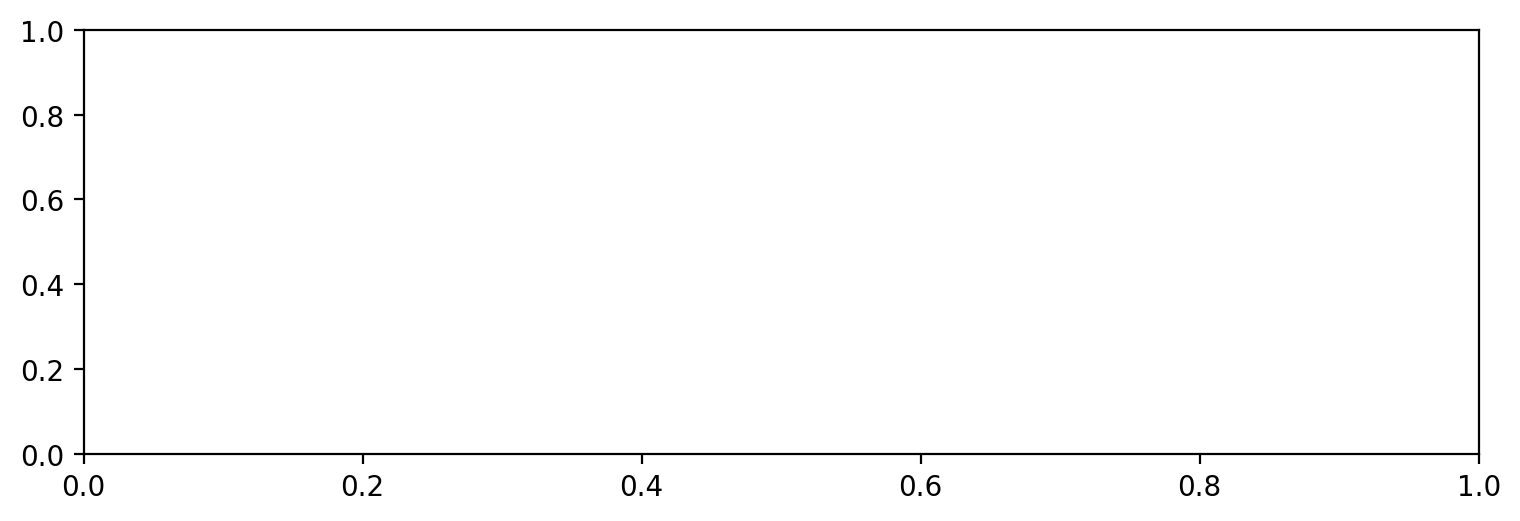

In [77]:
# Plot this to see how it looks
# Plot N2
fig, ax = plt.subplots(figsize=(9, 2.75), dpi=200)

#np.log10(n2_pdf.T.where(n2_pdf.T > 0)).plot()

# Plot N2
p1 = ax.pcolormesh(
    N2.ocean_time.values,
    n2_bins,
    np.log10(n2_pdf[:-1,:].T.where(n2_pdf[:-1,:].T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)


In [78]:
np.log10(n2_pdf[:-1,:].T.where(n2_pdf[:-1,:].T > 0))

<xarray.DataArray 'histogram_N2' (N2_bin: 59, ocean_time: 1439)> Size: 679kB
array([[-1.33177164, -1.33077337, -1.33047477, ..., -1.3168291 ,
        -1.31682898, -1.31682887],
       [-1.22621246, -1.22582082, -1.22550814, ..., -1.31499805,
        -1.31504602, -1.31504591],
       [-1.37102561, -1.37299955, -1.37415556, ..., -1.2534147 ,
        -1.25337286, -1.25337274],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])
Coordinates:
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
  * N2_bin      (N2_bin) float64 472B -5.475 -5.425 -5.375 ... -2.625 -2.575

In [79]:
print('min N2: ', np.min(np.log10(n2_pdf[:-1,:].T.where(n2_pdf[:-1,:].T > 0))))
print('max N2: ', np.max(np.log10(n2_pdf[:-1,:].T.where(n2_pdf[:-1,:].T > 0))))
print('mean N2: ', np.mean(np.log10(n2_pdf[:-1,:].T.where(n2_pdf[:-1,:].T > 0))))
print('std dev N2: ', np.std(np.log10(n2_pdf[:-1,:].T.where(n2_pdf[:-1,:].T > 0))))

min N2:  <xarray.DataArray 'histogram_N2' ()> Size: 8B
array(-1.37415556)
max N2:  <xarray.DataArray 'histogram_N2' ()> Size: 8B
array(0.53308657)
mean N2:  <xarray.DataArray 'histogram_N2' ()> Size: 8B
array(-0.54230163)
std dev N2:  <xarray.DataArray 'histogram_N2' ()> Size: 8B
array(0.52190631)


### Calculate Rossby Deformation Radius  
Can you estimate the deformation radius based on the initial conditions and include it here? The estimate is L = NH/f, where H is an effective length scale, roughly equal to the pycnocline depth. Then calculate the Burger and Richardson numbers? This is in Rob's 2017 paper. We want to better contextualize the parameter space. Kat thought the deformation radius in the region was like 1 km -- but obviously your realistic model and HYCOM show the eddies are about 1 degree across despite behaving like submesocales. We will want to discuss this in the intro / methods


In [43]:
# Use the mean N above to calculate the deformation radius
# Set the other values
# Effective length scale 
H = 50 # m
# Coriolis parameter 
f = 0.00013831 # second^(-1)
# N - stratification parameter
N_ini = np.sqrt(5.1e-5)
# Deformation radius
def_rad = (N_ini*H)/f
print('deformation radius: ', def_rad)

deformation radius:  2581.6746542342744


In [44]:
# Burger number
# Bu = (NH)/(fL)
# Horizontal length scale 
L = 500 # m
Bu = (N_ini*H)/(f*L)
print('Burger number: ', Bu)


Burger number:  5.16334930846855


In [45]:
# Richardson number
# Ri = N^2 H^2 / U^2 | N^2f^2 /M^4
N2_ini = 5.1e-5 
M4_ini = (4e-7)**2

Ri = (N2_ini*(f**2))/M4_ini
print('Richardson number: ', Ri)



Richardson number:  6.097577881875001
